# Caesar Infusion Sweep Analyzer

This notebook analyzes results from the Caesar infusion sweep experiments.
It can be run while the sweep is in progress to monitor results.

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Load Sweep Results from Wandb

In [2]:
# Initialize wandb API
api = wandb.Api()

# Load all runs from the sweep project
ENTITY = "jrosseruk"  # Your wandb entity/username
PROJECT = "caesar-infusion-sweep"

runs = api.runs(f"{ENTITY}/{PROJECT}")
print(f"Found {len(runs)} runs in {ENTITY}/{PROJECT}")

Found 20 runs in jrosseruk/caesar-infusion-sweep


In [3]:
# Since runs are "running", summary may not be synced yet
# Try fetching history instead which contains logged metrics
print(f"Total runs found: {len(runs)}")

data = []
for run in runs:
    print(f"\nProcessing {run.name} (state: {run.state})...")
    
    try:
        # Fetch history - this contains all wandb.log() calls
        history = run.history()
        print(f"  History rows: {len(history)}")
        
        if len(history) == 0:
            print("  No logged data yet")
            continue
        
        # Each row in history is one wandb.log() call (one experiment)
        for idx, row in history.iterrows():
            if 'targeting_score' not in row or pd.isna(row.get('targeting_score')):
                continue
                
            data.append({
                'targeting_score': row.get('targeting_score'),
                'delta_ce_correct': row.get('delta_ce_correct'),
                'delta_ce_target': row.get('delta_ce_target'),
                'delta_ce_other': row.get('delta_ce_other'),
                'margin_shift_target': row.get('margin_shift_target'),
                'margin_shift_correct': row.get('margin_shift_correct'),
                'top_k': row.get('top_k'),
                'epsilon': row.get('epsilon'),
                'alpha': row.get('alpha'),
                'n_steps': row.get('n_steps'),
                'n_probes': row.get('n_probes'),
                'probe_shift': row.get('probe_shift'),
                'target_shift': row.get('target_shift'),
                'noise_std': row.get('noise_std'),
                'elapsed_seconds': row.get('elapsed_seconds'),
                'config_seed': row.get('config_seed'),
                'run_id': run.id,
                'run_name': run.name,
                'worker_id': run.name.split('_')[1] if '_' in run.name else None,
            })
        print(f"  Found {len([r for r in data if r.get('run_id') == run.id])} experiments with targeting_score")
        
    except Exception as e:
        print(f"  Error: {e}")
        continue

df = pd.DataFrame(data)
print(f"\n{'='*60}")
print(f"Loaded {len(df)} completed experiments from {len(runs)} workers")
if len(df) > 0:
    display(df.head(10))

Total runs found: 20

Processing worker_01_20260107_151824 (state: running)...
  History rows: 1
  Found 1 experiments with targeting_score

Processing worker_00_20260107_151824 (state: running)...
  History rows: 0
  No logged data yet

Processing worker_02_20260107_151824 (state: running)...
  History rows: 0
  No logged data yet

Processing worker_03_20260107_151824 (state: running)...
  History rows: 3
  Found 3 experiments with targeting_score

Processing worker_09_20260107_151824 (state: running)...
  History rows: 1
  Found 1 experiments with targeting_score

Processing worker_08_20260107_151824 (state: running)...
  History rows: 2
  Found 2 experiments with targeting_score

Processing worker_10_20260107_151824 (state: running)...
  History rows: 1
  Found 1 experiments with targeting_score

Processing worker_17_20260107_151824 (state: running)...
  History rows: 1
  Found 1 experiments with targeting_score

Processing worker_18_20260107_151824 (state: running)...
  History row

,targeting_score,delta_ce_correct,delta_ce_target,delta_ce_other,margin_shift_target,margin_shift_correct,top_k,epsilon,alpha,n_steps,n_probes,probe_shift,target_shift,noise_std,elapsed_seconds,config_seed,run_id,run_name,worker_id
0,-0.011983,-0.001481,0.018754,0.006771,-0.020236,0,200,1,0.10000,100,1,20,24,1.0,674.982337,10000,1sh20h26,worker_01_20260107_151824,01
1,0.010623,0.001047,-0.020688,-0.010064,0.021735,0,100,1,0.00010,10,10,0,3,0.5,83.277975,30000,ad7pb5a4,worker_03_20260107_151824,03
2,0.540636,0.023756,-2.156129,-1.615493,2.063058,0,200,20,0.01000,50,100,11,22,0.0,347.166345,30001,ad7pb5a4,worker_03_20260107_151824,03
3,0.273579,0.052398,-1.556760,-1.283181,1.630193,0,50,20,0.01000,100,1000,14,23,0.0,337.983723,30002,ad7pb5a4,worker_03_20260107_151824,03
4,0.241034,0.048746,-0.178114,0.062921,0.221123,0,200,10,0.10000,50,100,1,17,0.5,382.367378,90000,cz4h8zwv,worker_09_20260107_151824,09
5,0.003520,0.000031,-0.003491,0.000029,0.003591,0,100,1,0.00001,50,1000,1,9,1.0,341.924907,80000,jdw5tmgo,worker_08_20260107_151824,08
6,0.055924,0.001051,-0.051452,0.004471,0.052504,0,100,1,0.00100,10,1,3,1,1.0,68.069651,80001,jdw5tmgo,worker_08_20260107_151824,08
7,0.003418,-0.007053,-0.007053,-0.003635,0.000000,0,50,100,0.10000,100,1000,23,23,1.0,356.606712,100000,k6til0uv,worker_10_20260107_151824,10
8,0.691389,0.031876,-0.773638,-0.082249,0.805682,0,50,20,0.01000,50,100,22,0,0.0,138.164781,170000,mlg1erks,worker_17_20260107_151824,17
9,0.018906,-0.000196,-0.015575,0.003330,0.015284,0,100,1,0.00001,50,100,18,12,0.5,213.918084,180000,rsab31vq,worker_18_20260107_151824,18


## 2. Summary Statistics

In [4]:
# Overall statistics
print("=" * 50)
print("Overall Targeting Score Statistics")
print("=" * 50)
print(df['targeting_score'].describe())
print(f"\nPositive targeting (good): {(df['targeting_score'] > 0).sum()} / {len(df)} ({100 * (df['targeting_score'] > 0).mean():.1f}%)")

Overall Targeting Score Statistics
count    30.000000
mean      0.180484
std       0.324322
min      -0.178387
25%       0.001398
50%       0.026377
75%       0.229102
max       1.138998
Name: targeting_score, dtype: float64

Positive targeting (good): 25 / 30 (83.3%)


In [5]:
# Best experiments
print("\nTop 10 Experiments by Targeting Score:")
top_cols = ['targeting_score', 'delta_ce_target', 'delta_ce_other', 
            'top_k', 'epsilon', 'alpha', 'n_steps', 'probe_shift', 'target_shift', 'noise_std']
df.nlargest(10, 'targeting_score')[top_cols]


Top 10 Experiments by Targeting Score:


,targeting_score,delta_ce_target,delta_ce_other,top_k,epsilon,alpha,n_steps,probe_shift,target_shift,noise_std
28,1.138998,-1.636735,-0.497737,400,10,0.0010,10,14,0,0.0
23,1.131757,-4.263859,-3.132101,400,10,0.0100,10,10,20,0.0
8,0.691389,-0.773638,-0.082249,50,20,0.0100,50,22,0,0.0
2,0.540636,-2.156129,-1.615493,200,20,0.0100,50,11,22,0.0
10,0.533066,-3.348408,-2.815342,400,10,0.1000,10,21,16,0.0
18,0.397712,-0.438505,-0.040793,200,1,0.0001,100,9,21,0.5
3,0.273579,-1.556760,-1.283181,50,20,0.0100,100,14,23,0.0
4,0.241034,-0.178114,0.062921,200,10,0.1000,50,1,17,0.5
21,0.193305,-0.183742,0.009564,50,1,0.0010,100,8,22,1.0
16,0.127647,-0.111845,0.015802,200,10,0.0010,10,7,11,1.0


## 3. Targeting Score Distribution

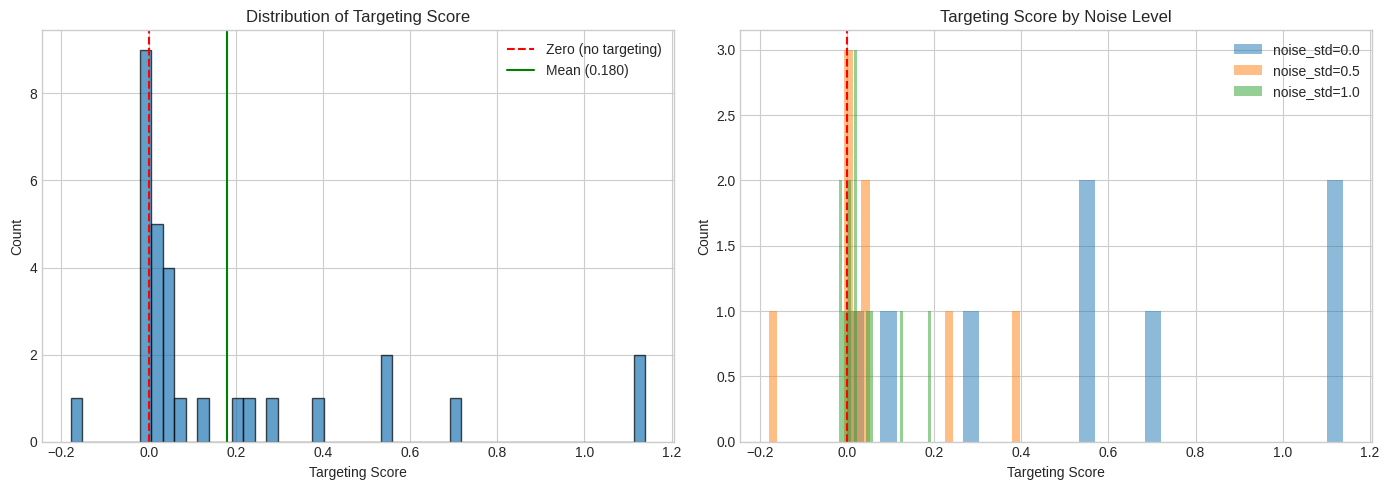

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(df['targeting_score'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', label='Zero (no targeting)')
ax.axvline(df['targeting_score'].mean(), color='green', linestyle='-', label=f'Mean ({df["targeting_score"].mean():.3f})')
ax.set_xlabel('Targeting Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Targeting Score')
ax.legend()

# By noise_std
ax = axes[1]
for noise_std in sorted(df['noise_std'].unique()):
    subset = df[df['noise_std'] == noise_std]
    ax.hist(subset['targeting_score'], bins=30, alpha=0.5, label=f'noise_std={noise_std}')
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Targeting Score')
ax.set_ylabel('Count')
ax.set_title('Targeting Score by Noise Level')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Hyperparameter Analysis

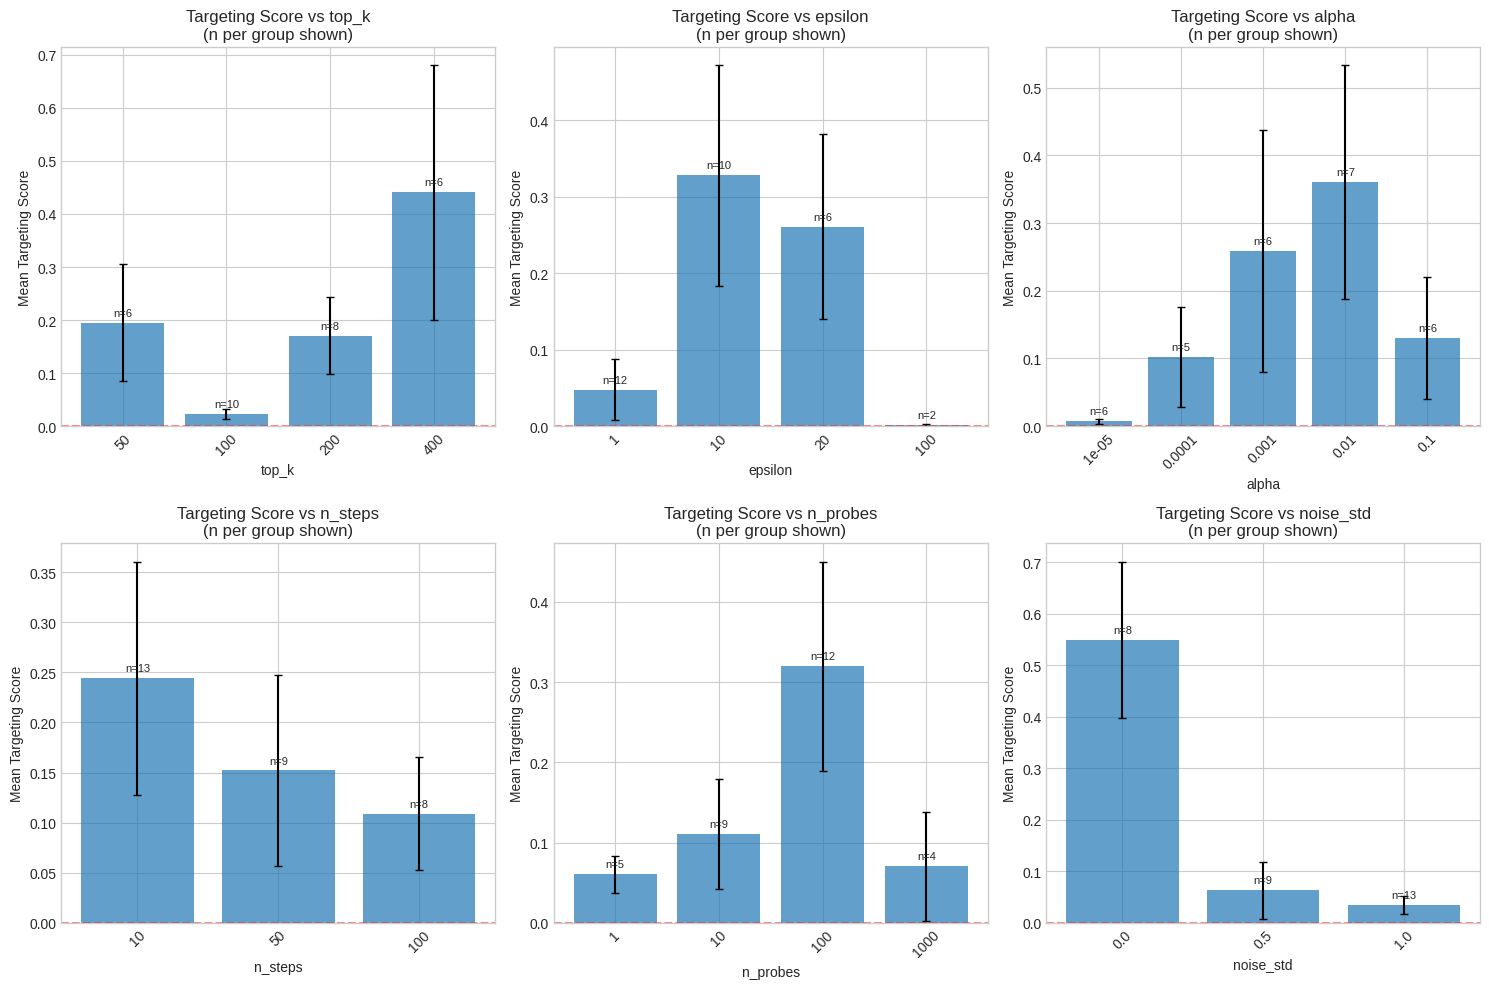

In [7]:
# Targeting score vs key hyperparameters
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

hp_params = ['top_k', 'epsilon', 'alpha', 'n_steps', 'n_probes', 'noise_std']

for ax, param in zip(axes.flat, hp_params):
    if param in df.columns and df[param].notna().any():
        # Group by parameter value
        grouped = df.groupby(param)['targeting_score'].agg(['mean', 'std', 'count'])
        
        # Bar plot with error bars
        x = range(len(grouped))
        ax.bar(x, grouped['mean'], yerr=grouped['std'] / np.sqrt(grouped['count']),
               capsize=3, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in grouped.index], rotation=45)
        ax.axhline(0, color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel(param)
        ax.set_ylabel('Mean Targeting Score')
        ax.set_title(f'Targeting Score vs {param}\n(n per group shown)')
        
        # Add count annotations
        for i, (idx, row) in enumerate(grouped.iterrows()):
            ax.annotate(f'n={int(row["count"])}', (i, row['mean']), 
                       textcoords='offset points', xytext=(0, 5), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

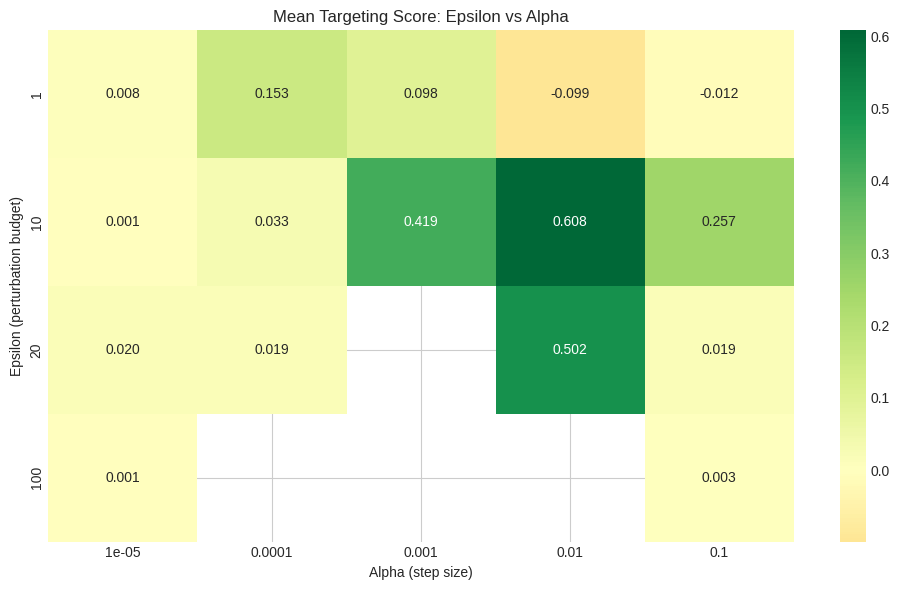

In [8]:
# Heatmap: epsilon vs alpha
if 'epsilon' in df.columns and 'alpha' in df.columns:
    pivot = df.pivot_table(values='targeting_score', index='epsilon', columns='alpha', aggfunc='mean')
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0)
    plt.title('Mean Targeting Score: Epsilon vs Alpha')
    plt.xlabel('Alpha (step size)')
    plt.ylabel('Epsilon (perturbation budget)')
    plt.tight_layout()
    plt.show()

## 5. Shift Analysis

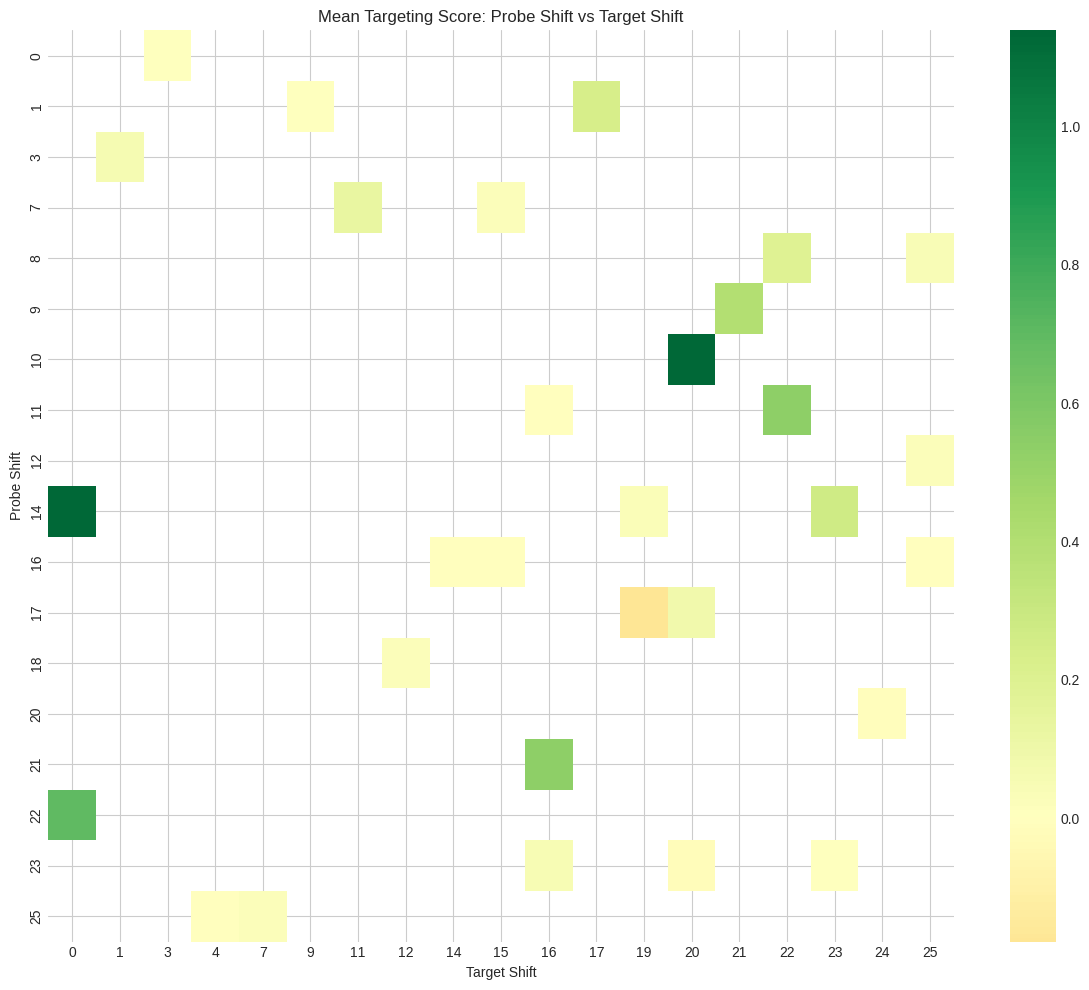

In [9]:
# Heatmap: probe_shift vs target_shift
if 'probe_shift' in df.columns and 'target_shift' in df.columns:
    pivot = df.pivot_table(values='targeting_score', index='probe_shift', 
                          columns='target_shift', aggfunc='mean')
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(pivot, annot=False, cmap='RdYlGn', center=0)
    plt.title('Mean Targeting Score: Probe Shift vs Target Shift')
    plt.xlabel('Target Shift')
    plt.ylabel('Probe Shift')
    plt.tight_layout()
    plt.show()

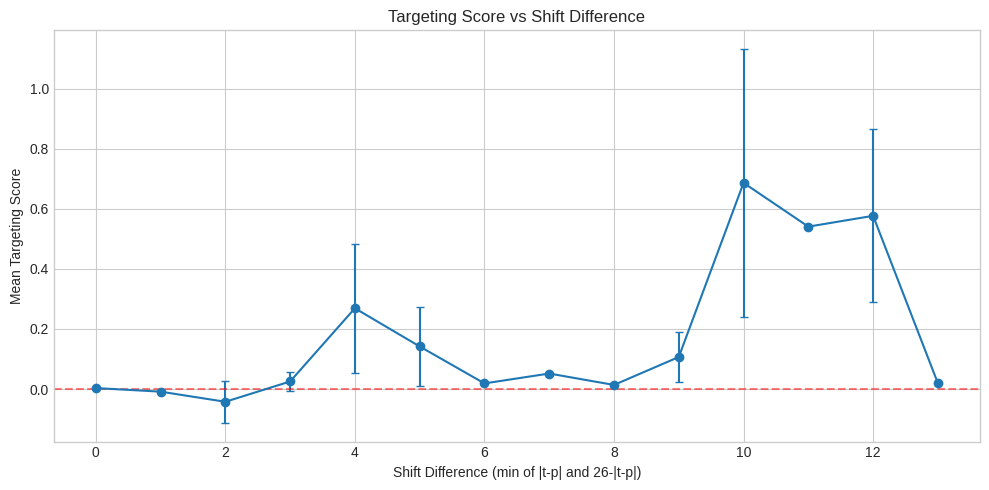

In [10]:
# Effect of shift difference
df['shift_diff'] = abs(df['target_shift'] - df['probe_shift'])
df['shift_diff_wrapped'] = df['shift_diff'].apply(lambda x: min(x, 26 - x))

plt.figure(figsize=(10, 5))
grouped = df.groupby('shift_diff_wrapped')['targeting_score'].agg(['mean', 'std', 'count'])
plt.errorbar(grouped.index, grouped['mean'], yerr=grouped['std'] / np.sqrt(grouped['count']),
            marker='o', capsize=3)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Shift Difference (min of |t-p| and 26-|t-p|)')
plt.ylabel('Mean Targeting Score')
plt.title('Targeting Score vs Shift Difference')
plt.tight_layout()
plt.show()

## 6. CE Change Analysis

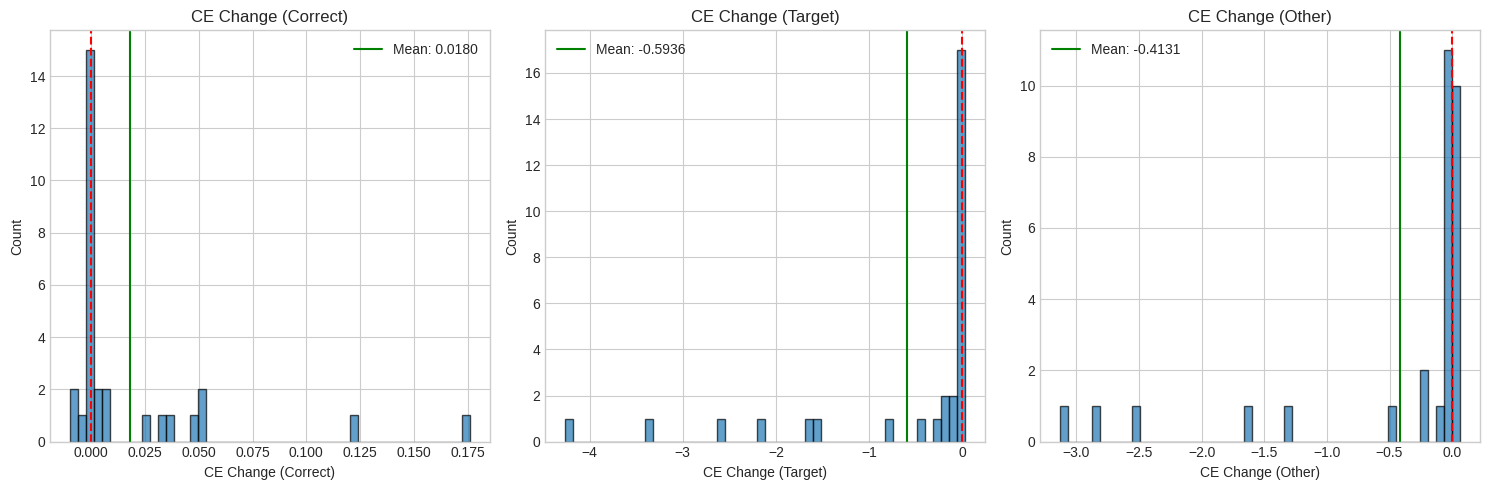

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes, 
                          ['delta_ce_correct', 'delta_ce_target', 'delta_ce_other'],
                          ['CE Change (Correct)', 'CE Change (Target)', 'CE Change (Other)']):
    if col in df.columns:
        ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7)
        ax.axvline(0, color='red', linestyle='--')
        ax.axvline(df[col].mean(), color='green', linestyle='-', label=f'Mean: {df[col].mean():.4f}')
        ax.set_xlabel(title)
        ax.set_ylabel('Count')
        ax.set_title(title)
        ax.legend()

plt.tight_layout()
plt.show()

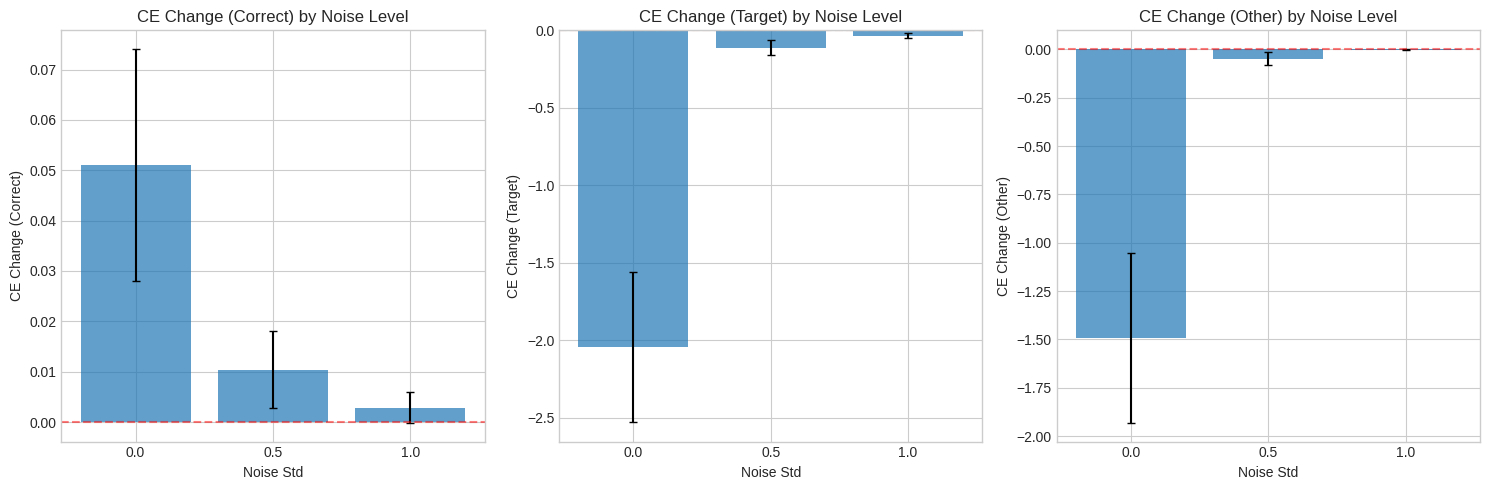

In [12]:
# CE changes by noise_std
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes,
                          ['delta_ce_correct', 'delta_ce_target', 'delta_ce_other'],
                          ['CE Change (Correct)', 'CE Change (Target)', 'CE Change (Other)']):
    if col in df.columns:
        grouped = df.groupby('noise_std')[col].agg(['mean', 'std', 'count'])
        x = range(len(grouped))
        ax.bar(x, grouped['mean'], yerr=grouped['std'] / np.sqrt(grouped['count']),
               capsize=3, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in grouped.index])
        ax.axhline(0, color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel('Noise Std')
        ax.set_ylabel(title)
        ax.set_title(f'{title} by Noise Level')

plt.tight_layout()
plt.show()

## 7. Progress Over Time

In [13]:
# Experiments over time
if 'created_at' in df.columns:
    df['created_at'] = pd.to_datetime(df['created_at'])
    df_sorted = df.sort_values('created_at')
    df_sorted['cumulative_count'] = range(1, len(df_sorted) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Cumulative experiments
    ax = axes[0]
    ax.plot(df_sorted['created_at'], df_sorted['cumulative_count'])
    ax.set_xlabel('Time')
    ax.set_ylabel('Cumulative Experiments')
    ax.set_title('Sweep Progress')
    plt.xticks(rotation=45)
    
    # Targeting score over time (running mean)
    ax = axes[1]
    window = min(50, len(df_sorted) // 10 + 1)
    df_sorted['targeting_score_rolling'] = df_sorted['targeting_score'].rolling(window=window).mean()
    ax.plot(df_sorted['created_at'], df_sorted['targeting_score_rolling'])
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Time')
    ax.set_ylabel(f'Targeting Score (rolling mean, window={window})')
    ax.set_title('Targeting Score Over Time')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

## 8. Worker Analysis

Worker Statistics:


,n_experiments,mean_targeting,std_targeting,mean_elapsed_s
worker_id,,,,
01,1,-0.012,NaN,674.982
03,3,0.275,0.265,256.143
04,2,0.570,0.805,277.644
05,2,0.477,0.926,413.587
08,2,0.030,0.037,204.997
09,1,0.241,NaN,382.367
10,1,0.003,NaN,356.607
11,2,0.074,0.076,411.796
12,3,0.064,0.113,181.375


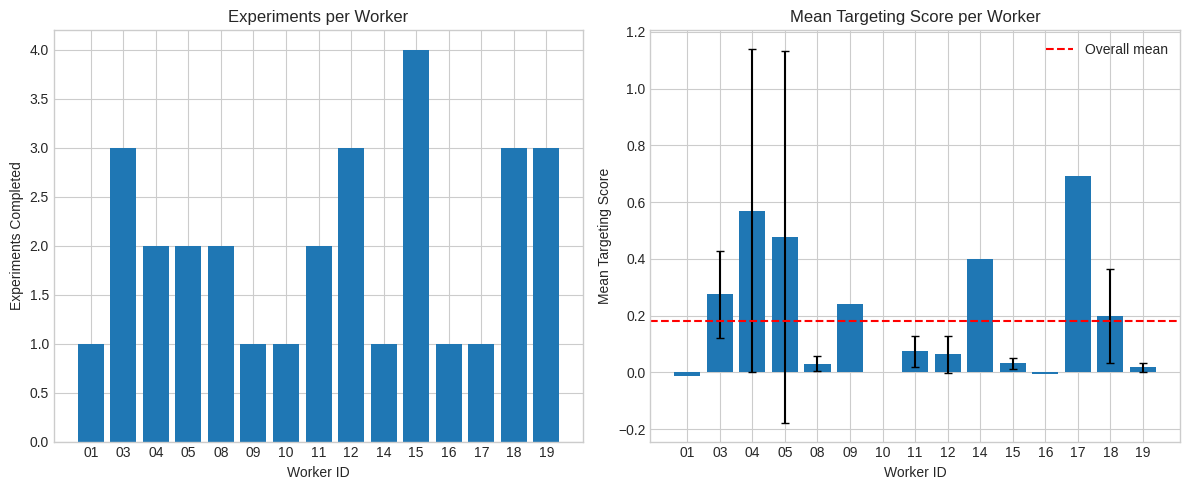

In [14]:
# Experiments per worker
if 'worker_id' in df.columns:
    worker_stats = df.groupby('worker_id').agg({
        'targeting_score': ['count', 'mean', 'std'],
        'elapsed_seconds': 'mean'
    }).round(3)
    worker_stats.columns = ['n_experiments', 'mean_targeting', 'std_targeting', 'mean_elapsed_s']
    
    print("Worker Statistics:")
    display(worker_stats)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Experiments per worker
    ax = axes[0]
    ax.bar(worker_stats.index, worker_stats['n_experiments'])
    ax.set_xlabel('Worker ID')
    ax.set_ylabel('Experiments Completed')
    ax.set_title('Experiments per Worker')
    
    # Mean targeting score per worker
    ax = axes[1]
    ax.bar(worker_stats.index, worker_stats['mean_targeting'],
           yerr=worker_stats['std_targeting'] / np.sqrt(worker_stats['n_experiments']),
           capsize=3)
    ax.axhline(df['targeting_score'].mean(), color='red', linestyle='--', label='Overall mean')
    ax.set_xlabel('Worker ID')
    ax.set_ylabel('Mean Targeting Score')
    ax.set_title('Mean Targeting Score per Worker')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

## 9. Export Results

In [15]:
# Save to CSV
output_path = 'sweep_results_summary.csv'
df.to_csv(output_path, index=False)
print(f"Saved {len(df)} experiments to {output_path}")

Saved 30 experiments to sweep_results_summary.csv


In [16]:
# Summary statistics for paper/report
print("\n" + "="*60)
print("SUMMARY FOR PAPER")
print("="*60)
print(f"Total experiments: {len(df)}")
print(f"Targeting score: {df['targeting_score'].mean():.4f} +/- {df['targeting_score'].std():.4f}")
print(f"Positive targeting rate: {100 * (df['targeting_score'] > 0).mean():.1f}%")
print(f"\nBest configuration:")
best = df.loc[df['targeting_score'].idxmax()]
print(f"  Targeting score: {best['targeting_score']:.4f}")
print(f"  top_k={best['top_k']}, epsilon={best['epsilon']}, alpha={best['alpha']}")
print(f"  n_steps={best['n_steps']}, n_probes={best['n_probes']}")
print(f"  probe_shift={best['probe_shift']}, target_shift={best['target_shift']}")
print(f"  noise_std={best['noise_std']}")


SUMMARY FOR PAPER
Total experiments: 30
Targeting score: 0.1805 +/- 0.3243
Positive targeting rate: 83.3%

Best configuration:
  Targeting score: 1.1390
  top_k=400, epsilon=10, alpha=0.001
  n_steps=10, n_probes=100
  probe_shift=14, target_shift=0
  noise_std=0.0
